In [1]:
import pandas as pd

In [2]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

In [3]:
train_df = pd.read_csv("KDDTrain+.txt", names=columns)
test_df = pd.read_csv("KDDTest+.txt", names=columns)

In [4]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
train_df.drop("difficulty", axis=1, inplace=True)
test_df.drop("difficulty", axis=1, inplace=True)

In [6]:
attack_mapping = {
    'normal': 'normal',

    # DoS
    'neptune': 'dos', 'smurf': 'dos', 'back': 'dos', 'teardrop': 'dos',
    'pod': 'dos', 'land': 'dos',

    # Probe
    'satan': 'probe', 'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe',

    # R2L
    'guess_passwd': 'r2l', 'ftp_write': 'r2l', 'imap': 'r2l',
    'phf': 'r2l', 'multihop': 'r2l', 'warezmaster': 'r2l',
    'warezclient': 'r2l', 'spy': 'r2l',

    # U2R
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r',
    'rootkit': 'u2r', 'perl': 'u2r'
}

In [7]:
train_df['label'] = train_df['label'].map(attack_mapping)
test_df['label'] = test_df['label'].map(attack_mapping)

In [8]:
print(train_df['label'].isnull().sum())

0


In [9]:
print(set(train_df['label']))
print(set(test_df['label']))

{'u2r', 'r2l', 'probe', 'dos', 'normal'}
{'u2r', 'r2l', nan, 'probe', 'dos', 'normal'}


In [10]:
train_df = train_df.dropna(subset=['label'])
test_df = test_df.dropna(subset=['label'])

In [11]:
print(set(train_df['label']))
print(set(test_df['label']))

{'u2r', 'r2l', 'probe', 'dos', 'normal'}
{'u2r', 'r2l', 'probe', 'dos', 'normal'}


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df['label'] = le.fit_transform(train_df['label'])
test_df['label'] = le.transform(test_df['label'])

In [15]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1


In [16]:
from sklearn.preprocessing import OneHotEncoder

In [17]:
cat_cols = ['protocol_type', 'service', 'flag']

In [18]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [19]:
encoded_train = encoder.fit_transform(train_df[cat_cols])
encoded_test = encoder.transform(test_df[cat_cols])

In [20]:
import pandas as pd

train_encoded_df = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(cat_cols))
test_encoded_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(cat_cols))

In [21]:
train_df = train_df.drop(columns=cat_cols)
test_df = test_df.drop(columns=cat_cols)

In [22]:
train_df = pd.concat([train_df.reset_index(drop=True), train_encoded_df], axis=1)
test_df = pd.concat([test_df.reset_index(drop=True), test_encoded_df], axis=1)

In [23]:
train_df.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,146,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0,232,8153,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,199,420,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [24]:
X = train_df.drop('label', axis=1)
y = train_df['label']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [27]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train, y_train = sm.fit_resample(X_train, y_train)

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [42]:
!pip install xgboost

In [43]:
from xgboost import XGBClassifier
print("XGBoost installed successfully")

XGBoost installed successfully


In [44]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [45]:
y_test_iso = (y_test != 0).astype(int)

In [46]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42
)

iso_model.fit(X_train)

IsolationForest(contamination=0.1, random_state=42)

In [47]:
iso_pred = iso_model.predict(X_test)

# convert -1/1 → 0/1
iso_pred = (iso_pred == -1).astype(int)

In [48]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

In [49]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Isolation Forest"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test_iso, iso_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Random Forest,0.999127
1,XGBoost,0.998611
2,Isolation Forest,0.400357


In [50]:
print("Random Forest")
print(classification_report(y_test, rf_pred))

print("XGBoost")
print(classification_report(y_test, xgb_pred))

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9186
           1       1.00      1.00      1.00     13469
           2       1.00      1.00      1.00      2331
           3       0.99      0.98      0.99       199
           4       0.83      1.00      0.91        10

    accuracy                           1.00     25195
   macro avg       0.97      1.00      0.98     25195
weighted avg       1.00      1.00      1.00     25195

XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9186
           1       1.00      1.00      1.00     13469
           2       1.00      0.99      1.00      2331
           3       0.99      0.99      0.99       199
           4       0.59      1.00      0.74        10

    accuracy                           1.00     25195
   macro avg       0.91      1.00      0.94     25195
weighted avg       1.00      1.00      1.00     25195



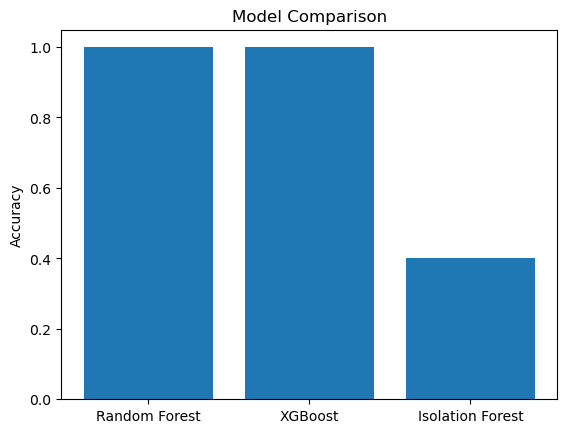

In [64]:
import matplotlib.pyplot as plt

plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()